# Southern Ocean SST trends: observations vs. CESM-HR vs. CESM-LR / CESM1-LE

Let us do a linear SST trends comparison between observations, CESM-HR, and CESM-LR similar to that in Figure 1 in the paper entitled [Ocean eddy compensation regulates feedbacks amplifying ozone-induced Southern Ocean cooling](https://www.researchgate.net/publication/406955938_Ocean_eddy_compensation_regulates_feedbacks_amplifying_ozone-induced_Southern_Ocean_cooling): linear SST trends (1980-2022) averaged over a South Pacific sector of the Southern Ocean, compared across observational products, CESM-HR (native grid, via uxarray), CESM-LR, and CESM1-LE, plus ensemble-mean spatial trend maps.

<!-- 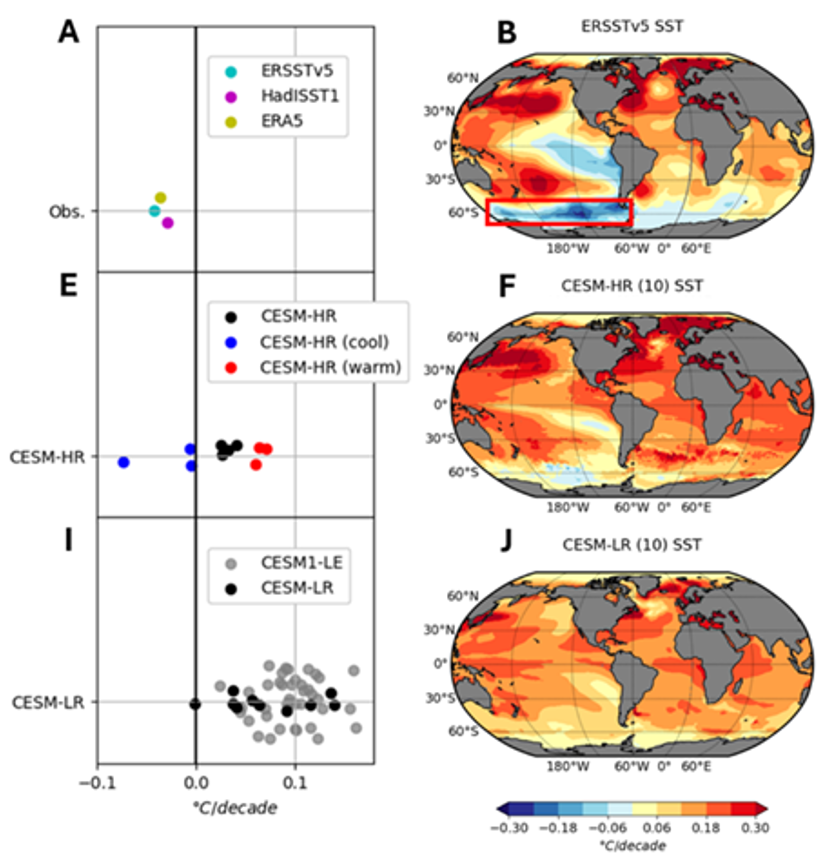 -->
<img src="refs/image.png" width="60%">

**Assumptions made explicit here:**
- Trend period: **1980-01 through 2022-12**, monthly data, slope reported in °C/decade.
- CESM-HR: the dedicated native-ocean-grid SST kerchunk product is used directly for members **003-010** — member **002** is excluded because its time coordinate seems corrupted beyond 1929.

## IMPORTS & DASK CONFIG

In [ ]:
import re
import gzip
import shutil
from pathlib import Path

import numpy as np
import xarray as xr
import uxarray as ux
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [ ]:
from dask.distributed import Client

# More headroom per worker than our first PRECT-notebook attempt — fewer, fatter workers.
client = Client(n_workers=10, threads_per_worker=2, memory_limit="7GB")
client.dashboard_link

In [ ]:
# Will measure peak notbook (kernel only) memory usage and displaye at the end
from distributed.diagnostics.memory_sampler import MemorySampler
ms = MemorySampler()
cm = ms.sample("full notebook")
cm.__enter__()

In [ ]:
# Will measure peak combined (kernel + dask workers) memory usage and displaye at the end
import os
import threading
import psutil

_peak_rss_bytes = 0
_stop_rss_watch = threading.Event()


def _watch_rss(interval=5):
    global _peak_rss_bytes
    root = psutil.Process(os.getpid())
    while not _stop_rss_watch.is_set():
        try:
            procs = [root] + root.children(recursive=True)
            total = sum(p.memory_info().rss for p in procs if p.is_running())
            _peak_rss_bytes = max(_peak_rss_bytes, total)
        except psutil.Error:
            pass
        _stop_rss_watch.wait(interval)


threading.Thread(target=_watch_rss, daemon=True).start()

In [ ]:
import logging
logging.getLogger("distributed.shuffle").setLevel(logging.ERROR)

## RUN CONFIG (Native Grid - only for CESM-HR)

In [ ]:
# Determine if notebook is to be run on local device or HPC

# The same pattern as the PRECT notebook) — however, only the CESM-HR kerchunk 
# source has an online-access variant; everything else here (obs products, 
# CESM-LR, CESM1-LE) is only verified to be available on Glade.

RUN_ON = 'hpc'  # 'local' | 'hpc'

if RUN_ON == 'local':
    KERCHUNK_PATH = "https://data.gdex.ucar.edu/d651007/kerchunk/"
    KERCHUNK_ACCESS = "-remote-osdf"
    KERCHUNK_REMOTE_PROTOCOL = "osdf"
    OCN_GRID_FILE = "tx0.1v2_070911.nc"  # would need to be staged locally too
elif RUN_ON == 'hpc':
    KERCHUNK_PATH = "/gdex/data/d651007/kerchunk/"
    KERCHUNK_ACCESS = ""
    KERCHUNK_REMOTE_PROTOCOL = "file"
    OCN_GRID_FILE = "/glade/p/cesmdata/cseg/inputdata/share/scripgrids/tx0.1v2_070911.nc"

In [ ]:
# CESM-HR: member 002's dedicated ocean SST kerchunk product has a corrupted time
# axis past 1929; use other members that has clean and complete records.
CESM_HR_MEMBERS = [3, 4, 5, 6, 7, 8, 9, 10]

CESM_LR_PATH = Path("/glade/campaign/univ/utam0017/High-Resolution_Modeling_Workshop_MESACLIP_dataset/CESM_LR/aave")
CESM1LE_SST_PATH = Path("/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/ocn/proc/tseries/monthly/SST")

ERSSTV5_DIR = Path("/glade/campaign/collections/rda/data/d277009/ersst.v5.nc")
HADISST_GZ = Path("/glade/campaign/collections/rda/data/d277003/HadISST_sst.nc.gz")
ERA5_SST_DIR = Path("/glade/campaign/collections/rda/data/d633001/e5.moda.an.sfc")

# Local cache for the one file that needs decompressing before xarray can open it
CACHE_DIR = Path("./_sst_trend_cache")
CACHE_DIR.mkdir(exist_ok=True)

In [ ]:
# Trend period and region
T_START = "1980-01-01"
T_END = "2022-12-31"

BOX_LON = (-180, -60)   # South Pacific sector of the Southern Ocean
BOX_LAT = (-75, -55)    # approximate red-box region from the reference figure

CENTRAL_LON = 300

MONTHS_PER_DECADE = 12 * 10

In [ ]:
# Shared colormap/levels for every spatial trend map, matching
# the reference figure's diverging ±0.30 °C/decade scale.
TREND_CMAP = "RdBu_r"
TREND_VMIN, TREND_VMAX = -0.30, 0.30

## HELPER FUNCTIONS: LINEAR TREND AND BOX MEAN

In [ ]:
def linear_trend_per_decade(da, time_dim="time"):
    """Can work on both uxarray and xarray data arrays. Ordinary Least Squares (OLS) 
    slope per decade (closed-form cov/var, not a per-point scipy loop) along
    `time_dim`, vectorized over every other dimension. Assumes monthly spacing."""
    n = da.sizes[time_dim]
    t_months = xr.DataArray(np.arange(n, dtype="float64"), dims=time_dim, coords={time_dim: da[time_dim]})
    t_anom = t_months - t_months.mean()
    y_anom = da - da.mean(dim=time_dim, skipna=True)
    slope_per_month = (t_anom * y_anom).sum(dim=time_dim, skipna=True) / (t_anom ** 2).sum(dim=time_dim)
    return slope_per_month * MONTHS_PER_DECADE


def _lon_to_180(lon):
    return ((lon + 180) % 360) - 180


def box_mean_latlon(da, lat_name="lat", lon_name="lon", weights=None):
    """Works only on xarray.DataArray. Area-weighted mean over BOX_LON/BOX_LAT 
    for a regular lat/lon DataArray. Longitude is normalized to -180..180 first 
    (BOX_LON is in that convention) regardless of the source's own convention, 
    then re-sorted since the modulo conversion can break monotonicity."""
    lon = _lon_to_180(da[lon_name])
    da = da.assign_coords({lon_name: lon}).sortby(lon_name)

    lat_vals = da[lat_name].values
    lat_slice = slice(*BOX_LAT) if lat_vals[0] < lat_vals[-1] else slice(*BOX_LAT[::-1])
    da_box = da.sel({lat_name: lat_slice, lon_name: slice(*BOX_LON)})

    if weights is not None:
        w = weights.assign_coords({lon_name: lon}).sortby(lon_name).sel(
            {lat_name: lat_slice, lon_name: slice(*BOX_LON)}
        )
    else:
        # cos(lat) is 1-D; xarray broadcasts it against da_box's other dims
        # (lon, and time if present) automatically in the arithmetic below.
        w = np.cos(np.deg2rad(da_box[lat_name]))
    w = w.where(da_box.notnull())
    return (da_box * w).sum(dim=[lat_name, lon_name], skipna=True) / w.sum(dim=[lat_name, lon_name], skipna=True)


def box_mean_uxarray(uxda):
    """Works only on uxarray.UxDataArray. Area-weighted mean over BOX_LON/BOX_LAT 
    for a UxDataArray, using its own face_areas as weights (zeroed outside the box)."""
    lon = _lon_to_180(uxda.uxgrid.face_lon.values)
    lat = uxda.uxgrid.face_lat.values
    in_box = (lon >= BOX_LON[0]) & (lon <= BOX_LON[1]) & (lat >= BOX_LAT[0]) & (lat <= BOX_LAT[1])
    w = xr.DataArray(np.where(in_box, uxda.uxgrid.face_areas.values, 0.0), dims="n_face")
    return (uxda * w).sum(dim="n_face", skipna=True) / w.sum()

## OBSERVATIONS: ERSSTv5, HadISST1, ERA5

- **ERSSTv5**: `ersst.v5.nc` is a *directory* of one file per month — `sst` in °C, 2° grid, longitude 0-360.
- **HadISST1**: a single global monthly file, but distributed gzip-compressed
  (`HadISST_sst.nc.gz`) — decompressed once into a local cache directory since
  xarray can't read a gzip-compressed netCDF container directly. Longitude is
  already -180..180; missing/land values use a large negative fill value, not
  NaN, so those get masked explicitly. 1° grid.
- **ERA5**: one file per year, variable `SSTK` in **Kelvin** — converted to °C, 0.25° grid.

In [ ]:
def open_ersstv5(t0=T_START, t1=T_END):
    hits = sorted(ERSSTV5_DIR.glob("ersst.v5.??????.nc"))
    hits = [p for p in hits if t0[:4] + t0[5:7] <= p.name.split(".")[2] <= t1[:4] + t1[5:7]]
    ds = xr.open_mfdataset(hits, combine="nested", concat_dim="time", chunks={"time": 60})
    return ds["sst"].isel(lev=0, drop=True)

In [ ]:
%%time
sst_ersstv5 = open_ersstv5()
sst_ersstv5

In [ ]:
%%time
trend_ersstv5 = linear_trend_per_decade(sst_ersstv5).compute()
box_trend_ersstv5 = float(box_mean_latlon(trend_ersstv5))
print("ERSSTv5 box-mean trend (°C/decade):", box_trend_ersstv5)

In [ ]:
def plot_trend_map_latlon(trend_da, title, lat_name="lat", lon_name="lon", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": ccrs.Robinson(central_longitude=CENTRAL_LON)})
    im = ax.pcolormesh(
        trend_da[lon_name], trend_da[lat_name], trend_da,
        transform=ccrs.PlateCarree(), cmap=TREND_CMAP, vmin=TREND_VMIN, vmax=TREND_VMAX,
    )
    ax.coastlines()
    ax.set_title(title)
    return im

In [ ]:
%%time
im = plot_trend_map_latlon(trend_ersstv5, "ERSSTv5 SST trend 1980-2022")
plt.colorbar(im, orientation="horizontal", pad=0.05, label="°C/decade")
plt.show()

In [ ]:
def open_hadlsst(t0=T_START, t1=T_END):
    cached = CACHE_DIR / "HadISST_sst.nc"
    if not cached.exists():
        with gzip.open(HADISST_GZ, "rb") as f_in, open(cached, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
    ds = xr.open_dataset(cached, chunks={"time": 60})
    sst = ds["sst"].where(ds["sst"] > -900)  # land/missing is a literal -1000.0, not NaN
    return sst.sel(time=slice(t0, t1))


sst_hadisst = open_hadlsst()
sst_hadisst

In [ ]:
%%time
box_series_hadisst = box_mean_latlon(sst_hadisst, lat_name="latitude", lon_name="longitude")
box_trend_hadisst = float(linear_trend_per_decade(box_series_hadisst).compute())
print("HadISST1 box-mean trend (°C/decade):", box_trend_hadisst)

In [ ]:
def open_era5_sst(t0=T_START, t1=T_END):
    years = range(int(t0[:4]), int(t1[:4]) + 1)
    hits = []
    for y in years:
        hits += sorted((ERA5_SST_DIR / str(y)).glob(f"e5.moda.an.sfc.128_034_sstk.ll025sc.{y}*.nc"))
    ds = xr.open_mfdataset(hits, combine="by_coords", chunks={"time": 12})
    sstk = ds["SSTK"].sel(time=slice(t0, t1))
    sst = sstk - 273.15
    sst.attrs["units"] = "degC"
    return sst

In [ ]:
%%time
sst_era5 = open_era5_sst()
sst_era5

In [ ]:
%%time
box_series_era5 = box_mean_latlon(sst_era5, lat_name="latitude", lon_name="longitude")
box_trend_era5 = float(linear_trend_per_decade(box_series_era5).compute())
print("ERA5 box-mean trend (°C/decade):", box_trend_era5)

In [ ]:
fig, ax = plt.subplots(figsize=(5, 1.5))
obs_trends = {"ERSSTv5": box_trend_ersstv5, "HadISST1": box_trend_hadisst, "ERA5": box_trend_era5}
colors = {"ERSSTv5": "teal", "HadISST1": "magenta", "ERA5": "olive"}
for name, val in obs_trends.items():
    ax.scatter(val, 0, color=colors[name], label=name, s=60, zorder=3)
ax.axvline(0, color="black", lw=1)
ax.set_xlim(-0.15, 0.15)
ax.set_yticks([])
ax.set_xlabel("°C/decade")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.set_title("Obs.")
plt.tight_layout()
plt.show()

## CESM-HR: NATIVE GRID (uxarray)

The native ocean grid is a ~0.1° curvilinear grid (~8.64M cells) — a SCRIP grid 
file for it (`tx0.1v2_070911.nc`) is present in CESM's shared `inputdata` dir.

The kerchunk source stores `SST` as `(time, nlat, nlon)` though, i.e. not already 
flattened to one spatial dimension, i.e. `n_face` in this case; hence, we `.stack()`
into a single `n_face` dimension before wrapping as a `UxDataArray`.

**This is the most expensive section in the notebook** — the global ensemble-mean
trend map (like panel F in the reference figure) means computing a per-gridcell linear regression over 516
months × 8 members × 8.64M cells.

In [ ]:
%%time
uxgrid_hr_ocn = ux.open_grid(OCN_GRID_FILE)
uxgrid_hr_ocn

In [ ]:
def open_hr_sst_member(member, t0=T_START, t1=T_END):
    hits = sorted(Path(KERCHUNK_PATH).glob(f"*.{member:03d}.ocn.month_1.sst_only{KERCHUNK_ACCESS}.parq"))
    if not hits:
        return None

    ds = xr.open_dataset(
        str(hits[0]), engine="kerchunk", decode_timedelta=False,
        decode_times=xr.coders.CFDatetimeCoder(use_cftime=True),
        chunks={"time": 60},
        
        # To avoid the "boolean value of NA is ambiguous" error.
        storage_options={"remote_protocol": KERCHUNK_REMOTE_PROTOCOL},
    )
    sst = ds["SST"].sel(time=slice(t0, t1))
    
    # Flatten (nlat, nlon) -> n_face
    sst = sst.stack(n_face=("nlat", "nlon")).reset_index("n_face", drop=True)
    
    return ux.UxDataArray(sst, uxgrid=uxgrid_hr_ocn)

In [ ]:
%%time
# Opened lazily only (similar to the first notebook, i.e. PRECT)
hr_members = {m: open_hr_sst_member(m) for m in CESM_HR_MEMBERS}
hr_members[CESM_HR_MEMBERS[0]]

In [ ]:
%%time
# Box-mean trend per member. Cheap (a single area-weighted scalar
# reduction per member) — build all 8 members' graphs and compute once so dask
# schedules them as one parallel graph, same pattern as the PRECT ensemble cell.
hr_box_series = {m: box_mean_uxarray(hr_members[m]) for m in CESM_HR_MEMBERS}
hr_box_trend_da = xr.concat(
    [linear_trend_per_decade(s) for s in hr_box_series.values()], dim="member"
).assign_coords(member=list(hr_box_series.keys()))
hr_box_trend_da = hr_box_trend_da.compute()

hr_box_trends = dict(zip(hr_box_trend_da["member"].values, hr_box_trend_da.values))
hr_box_trends

In [ ]:
# Classify into coolest-3 / warmest-3 / remaining, same idea as the reference
# figure's panel E (which does this over 10 members; we have 8, so 3 cool + 3
# warm leaves 2 in the middle instead of 4).
ranked = sorted(hr_box_trends.items(), key=lambda kv: kv[1])
cool_members = dict(ranked[:3])
warm_members = dict(ranked[-3:])
mid_members = dict(ranked[3:-3])

fig, ax = plt.subplots(figsize=(5, 1.5))
for members, color, label in [(mid_members, "black", "CESM-HR"),
                                (cool_members, "blue", "CESM-HR (cool)"),
                                (warm_members, "red", "CESM-HR (warm)")]:
    ax.scatter(list(members.values()), [0] * len(members), color=color, label=label, s=60, zorder=3)
ax.axvline(0, color="black", lw=1)
ax.set_xlim(-0.15, 0.15)
ax.set_yticks([])
ax.set_xlabel("°C/decade")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.set_title("CESM-HR")
plt.tight_layout()
plt.show()

In [ ]:
%%time
# Ensemble-mean spatial trend map — the expensive one (see markdown
# above). Mean-of-trends (each member's own trend map, then averaged), not
# trend-of-the-ensemble-mean-SST — matches how the reference figure's caption
# phrases "ensemble-mean linear trends in CESM-HR".
hr_member_trend_maps = [linear_trend_per_decade(hr_members[m]) for m in CESM_HR_MEMBERS]
hr_ensemble_mean_trend = xr.concat(hr_member_trend_maps, dim="member").mean(dim="member")
hr_ensemble_mean_trend = hr_ensemble_mean_trend.compute()

In [ ]:
hr_ensemble_mean_trend = ux.UxDataArray(hr_ensemble_mean_trend, uxgrid=uxgrid_hr_ocn)

In [ ]:
%%time
hr_ensemble_mean_trend.plot(
    cmap=TREND_CMAP, clim=(TREND_VMIN, TREND_VMAX),
    projection=ccrs.Robinson(central_longitude=CENTRAL_LON),
    title="CESM-HR ensemble-mean SST trend 1980-2022 (°C/decade)",
)

## CESM-LR: REGRIDDED (aave)

Already on a regular lat/lon grid (`nlat`/`nlon`), but `lat`/`lon` are stored as
plain 1-D *data variables* aligned to those dims, not as actual dimension
coordinates — `.assign_coords()` promotes them so `box_mean_latlon()`'s `.sel()`
calls work. Each member is split across a historical (1920-2005) and an RCP8.5
continuation (2006-2100) file; sorting the two filenames puts historical first
("BHISTC5" < "BRCP85C5" alphabetically) so `combine="nested"` can trust that
order instead of inspecting each file's time coordinate first.

In [ ]:
CESM_LR_MEMBERS = sorted(
    int(p.name.split(".")[-1])
    for p in CESM_LR_PATH.glob("b.e13.ne30_g16.cesm-ihesp-hires1.[0-9][0-9][0-9]")
)
print(f"{len(CESM_LR_MEMBERS)} CESM-LR members:", CESM_LR_MEMBERS)

In [ ]:
def open_lr_sst_member(member, t0=T_START, t1=T_END):
    member_dir = CESM_LR_PATH / f"b.e13.ne30_g16.cesm-ihesp-hires1.{member:03d}" / "ocn" / "mon"
    hits = sorted(member_dir.glob("*.pop.h.tos.*.nc"))
    if not hits:
        return None

    ds = xr.open_mfdataset(
        hits, combine="nested", concat_dim="time",
        decode_times=xr.coders.CFDatetimeCoder(use_cftime=True),
        decode_timedelta=False, chunks={"time": 120},
        data_vars="minimal", coords="minimal", compat="override",
    )
    # lat/lon are plain 1-D data variables (indexed by nlat, nlon respectively),
    # not dimension coordinates. Renaming nlat/nlon straight to lat/lon would
    # collide with those existing variable names, so drop them first and
    # reattach the same values as real coordinates under the new dim names —
    # this renames "area" (and everything else sharing nlat/nlon) as well.
    lat_vals, lon_vals = ds["lat"].values, ds["lon"].values
    ds = ds.drop_vars(["lat", "lon"]).rename(nlat="lat", nlon="lon")
    ds = ds.assign_coords(lat=("lat", lat_vals), lon=("lon", lon_vals))
    sst = ds["tos"].isel(z_t=0, drop=True).sel(time=slice(t0, t1))
    return sst, ds["area"]

In [ ]:
%%time
sst_lr_002, area_lr = open_lr_sst_member(CESM_LR_MEMBERS[0])
sst_lr_002

In [ ]:
%%time
# Opened lazily only, same reasoning as CESM-HR above.
lr_members = {}
lr_area = None
for m in CESM_LR_MEMBERS:
    sst, area = open_lr_sst_member(m)
    lr_members[m] = sst
    if lr_area is None:
        lr_area = area  # identical regridded grid/area for every member

In [ ]:
%%time
# (Black dots): box-mean trend per CESM-LR member.
lr_box_series = {m: box_mean_latlon(lr_members[m], weights=lr_area) for m in CESM_LR_MEMBERS}
lr_box_trend_da = xr.concat(
    [linear_trend_per_decade(s) for s in lr_box_series.values()], dim="member"
).assign_coords(member=CESM_LR_MEMBERS)
lr_box_trend_da = lr_box_trend_da.compute()
lr_box_trends = dict(zip(lr_box_trend_da["member"].values, lr_box_trend_da.values))
lr_box_trends

In [ ]:
%%time
# Ensemble-mean spatial trend map. Only 1° x 21 members x 516 months —
# far cheaper than the CESM-HR native-grid equivalent.
lr_member_trend_maps = [linear_trend_per_decade(lr_members[m]) for m in CESM_LR_MEMBERS]
lr_ensemble_mean_trend = xr.concat(lr_member_trend_maps, dim="member").mean(dim="member").compute()

im = plot_trend_map_latlon(lr_ensemble_mean_trend, "CESM-LR ensemble-mean SST trend 1980-2022")
plt.colorbar(im, orientation="horizontal", pad=0.05, label="°C/decade")
plt.show()

## CESM1-LE: full ensemble

Native gx1v6 POP grid (curvilinear `TLAT`/`TLONG`, static — no spurious time
dimension on the coordinates the way the CESM-HR product briefly had for member
002). Only a box-mean trend is needed here (no spatial map), so this uses a
lightweight curvilinear box-mean directly on `TLAT`/`TLONG`/`TAREA` rather than
building a full uxarray `Grid` for a grid we only ever reduce to one number per
member.

File discovery mirrors the same idea as `open_regridded_member` in the PRECT
notebook: glob, exclude irrelevant variants (here, the `OIC` sensitivity-run
files, which end in 1999 and aren't part of the main 40-member ensemble), and
match historical (`20TRC5CNBDRD`, 1920-2005) with its RCP8.5 continuation
(`RCP85C5CNBDRD`, 2006-2100) per member. This resolves to the canonical 40-member
ensemble (members 001-035, 101-105).

In [ ]:
_CESM1LE_RE = re.compile(r"\.B(20TRC5CNBDRD|RCP85C5CNBDRD)\.f09_g16\.(\d+)\.pop\.h\.SST\.")


def discover_cesm1le_members():
    hist_files, rcp_files = {}, {}
    for p in CESM1LE_SST_PATH.glob("*.pop.h.SST.*.nc"):
        if "OIC" in p.name:
            continue
        m = _CESM1LE_RE.search(p.name)
        if not m:
            continue
        exp, member = m.groups()
        (hist_files if exp == "20TRC5CNBDRD" else rcp_files)[member] = p

    return {
        member: sorted([hp] + ([rcp_files[member]] if member in rcp_files else []))
        for member, hp in hist_files.items()
        if member in rcp_files  # need the RCP8.5 continuation to reach 2022
    }


def open_cesm1le_sst_member(files, t0=T_START, t1=T_END):
    ds = xr.open_mfdataset(
        files, combine="nested", concat_dim="time",
        decode_times=xr.coders.CFDatetimeCoder(use_cftime=True),
        decode_timedelta=False, chunks={"time": 120},
        data_vars="minimal", coords="minimal", compat="override",
    )
    sst = ds["SST"].isel(z_t=0, drop=True).sel(time=slice(t0, t1))
    return sst, ds["TLAT"], ds["TLONG"], ds["TAREA"]


def box_mean_curvilinear(da, tlat, tlon, area):
    lon = _lon_to_180(tlon)
    in_box = (lon >= BOX_LON[0]) & (lon <= BOX_LON[1]) & (tlat >= BOX_LAT[0]) & (tlat <= BOX_LAT[1])
    w = area.where(in_box).where(da.notnull())
    return (da * w).sum(dim=["nlat", "nlon"], skipna=True) / w.sum(dim=["nlat", "nlon"], skipna=True)

In [ ]:
%%time
cesm1le_files = discover_cesm1le_members()
print(f"{len(cesm1le_files)} CESM1-LE members:", sorted(cesm1le_files))

In [ ]:
%%time
# Opened + reduced to a box-mean series member by member (not batched into one
# big concat-then-compute like the other sections) — 40 members x static
# curvilinear coordinates is enough files that building one combined graph
# isn't necessary for a reduction this cheap, and doing it one at a time keeps
# any single bad/missing member from failing the whole batch.
cesm1le_box_trends = {}
for member, files in cesm1le_files.items():
    sst, tlat, tlon, tarea = open_cesm1le_sst_member(files)
    box_series = box_mean_curvilinear(sst, tlat, tlon, tarea)
    cesm1le_box_trends[member] = float(linear_trend_per_decade(box_series).compute())

cesm1le_box_trends

In [ ]:
rng = np.random.default_rng(0)  # small vertical jitter so overlapping dots stay visible

fig, ax = plt.subplots(figsize=(5, 1.8))
le_vals = list(cesm1le_box_trends.values())
ax.scatter(le_vals, rng.uniform(-0.3, 0.3, size=len(le_vals)), color="lightgray", label="CESM1-LE", s=40, zorder=2)
lr_vals = list(lr_box_trends.values())
ax.scatter(lr_vals, rng.uniform(-0.15, 0.15, size=len(lr_vals)), color="black", label="CESM-LR", s=40, zorder=3)
ax.axvline(0, color="black", lw=1)
ax.set_xlim(-0.15, 0.15)
ax.set_yticks([])
ax.set_xlabel("°C/decade")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.set_title("CESM-LR")
plt.tight_layout()
plt.show()

In [ ]:
cm.__exit__(None, None, None)
ms.plot()

In [ ]:
_stop_rss_watch.set()
print(f"Peak combined RSS (kernel + dask workers): {_peak_rss_bytes / 1e9:.2f} GB")

In [ ]:
client.close()